# **Análisis exploratorio de datos**

### *Default clients*

0. Importación de librerias 

In [7]:
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


1. Carga de datos 

In [10]:
ruta_archivo = "../data/raw/Default_Clientes.csv"
df = pd.read_csv(ruta_archivo, sep=";")

print("\n--- Estructura inicial del Dataset ---")
print(df.info())
print("\n", df.describe())


--- Estructura inicial del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-

2. Limpieza e imputación 

In [12]:
cols_numericas = df.select_dtypes(include=[np.number]).columns
cols_texto = df.select_dtypes(include=['object']).columns

# Imputación: mediana para numéricas, moda para categóricas
df[cols_numericas] = df[cols_numericas].fillna(df[cols_numericas].median())

if not cols_texto.empty:
    for col in cols_texto:
        df[col] = df[col].fillna(df[col].mode()[0])

# Convertir variables que conceptualmente son categóricas al tipo 'category'
cols_categoricas = ["SEX", "EDUCATION", "MARRIAGE", "PAY_0", "PAY_2", "PAY_3", 
                    "PAY_4", "PAY_5", "PAY_6", "Default"]

for col in cols_categoricas:
    if col in df.columns:
        df[col] = df[col].astype('category')
    else:
        print(f"Advertencia: columna '{col}' no encontrada")

print("\nColumnas categóricas convertidas exitosamente")
print(f"Columnas categóricas: {df.select_dtypes(include=['category']).columns.tolist()}")


Columnas categóricas convertidas exitosamente
Columnas categóricas: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'Default']


3. ESTADÍSTICAS DESCRIPTIVAS POST-LIMPIEZA

In [ ]:
print("\n--- Resumen de Datos Limpios ---")
print(df.describe(include='all'))

4. VISUALIZACIÓN DE DATOS

C:\Users\Usuario\AppData\Local\Temp\ipykernel_2172\477940432.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Default', palette='Set2', edgecolor='black')


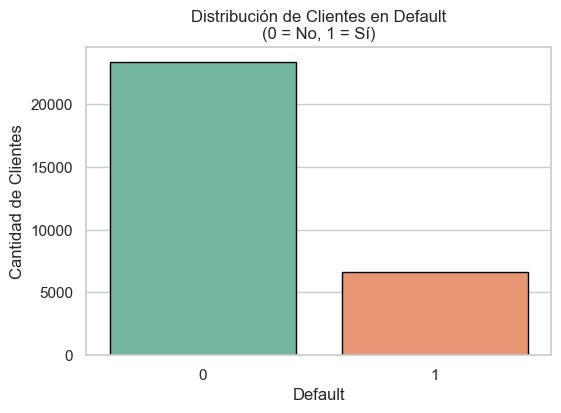

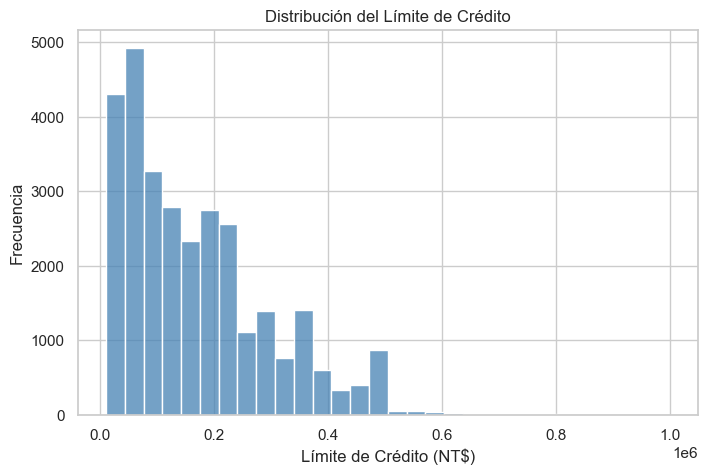

C:\Users\Usuario\AppData\Local\Temp\ipykernel_2172\477940432.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Default', y='LIMIT_BAL', palette='Set2')


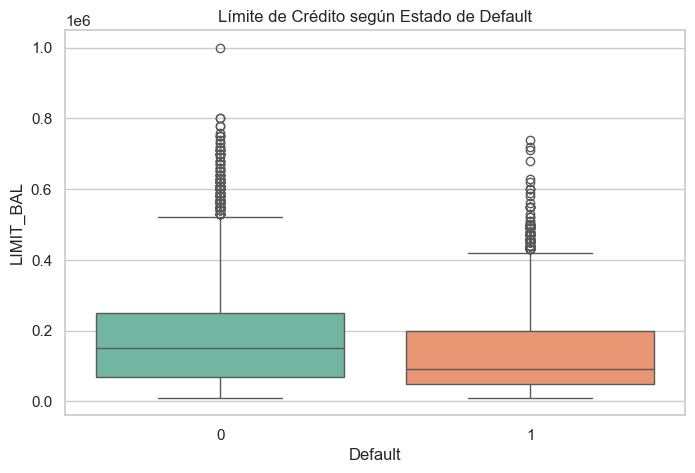

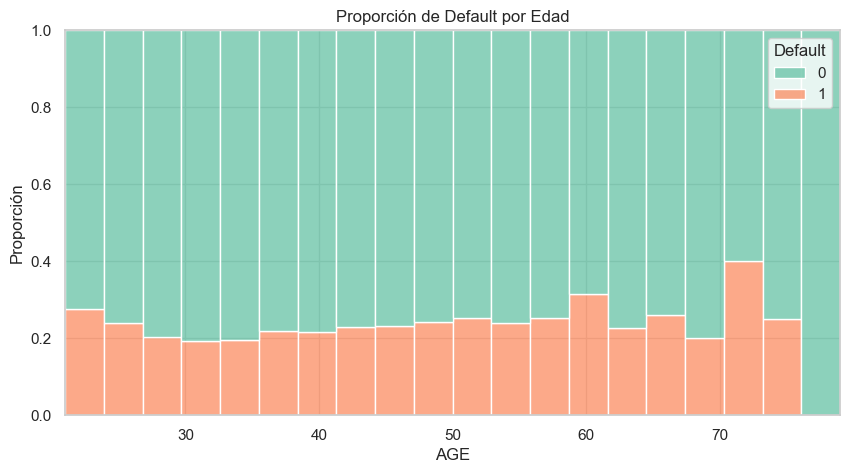

In [13]:
sns.set_theme(style="whitegrid")

# a) Distribución de la variable objetivo (Default)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Default', palette='Set2', edgecolor='black')
plt.title('Distribución de Clientes en Default\n(0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Clientes')
plt.show()

# b) Histograma del límite de crédito (LIMIT_BAL)
plt.figure(figsize=(8, 5))
sns.histplot(df['LIMIT_BAL'], bins=30, color='steelblue', kde=False)
plt.title('Distribución del Límite de Crédito')
plt.xlabel('Límite de Crédito (NT$)')
plt.ylabel('Frecuencia')
plt.show()

# c) Boxplot de Límite de crédito vs Default
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Default', y='LIMIT_BAL', palette='Set2')
plt.title('Límite de Crédito según Estado de Default')
plt.show()

# d) Relación entre Edad e Impagos (Proporción)
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='AGE', hue='Default', multiple='fill', bins=20, palette='Set2')
plt.title('Proporción de Default por Edad')
plt.ylabel('Proporción')
plt.show()

5. PRUEBAS DE NORMALIDAD Y CORRELACIÓN 


--- Evaluación de Normalidad (Asimetría y Curtosis) ---
Variable: LIMIT_BAL - ¿Aceptable? Sí (Asimetría: 0.99, Curtosis: 0.54)
Variable: AGE - ¿Aceptable? Sí (Asimetría: 0.73, Curtosis: 0.04)
Variable: BILL_AMT1 - ¿Aceptable? No (Asimetría: 2.66, Curtosis: 9.81)
Variable: BILL_AMT2 - ¿Aceptable? No (Asimetría: 2.71, Curtosis: 10.30)
Variable: BILL_AMT3 - ¿Aceptable? No (Asimetría: 3.09, Curtosis: 19.78)
Variable: BILL_AMT4 - ¿Aceptable? No (Asimetría: 2.82, Curtosis: 11.31)
Variable: BILL_AMT5 - ¿Aceptable? No (Asimetría: 2.88, Curtosis: 12.31)
Variable: BILL_AMT6 - ¿Aceptable? No (Asimetría: 2.85, Curtosis: 12.27)
Variable: PAY_AMT1 - ¿Aceptable? No (Asimetría: 14.67, Curtosis: 415.25)
Variable: PAY_AMT2 - ¿Aceptable? No (Asimetría: 30.45, Curtosis: 1641.63)
Variable: PAY_AMT3 - ¿Aceptable? No (Asimetría: 17.22, Curtosis: 564.31)
Variable: PAY_AMT4 - ¿Aceptable? No (Asimetría: 12.90, Curtosis: 277.33)
Variable: PAY_AMT5 - ¿Aceptable? No (Asimetría: 11.13, Curtosis: 180.06)
Variable: 

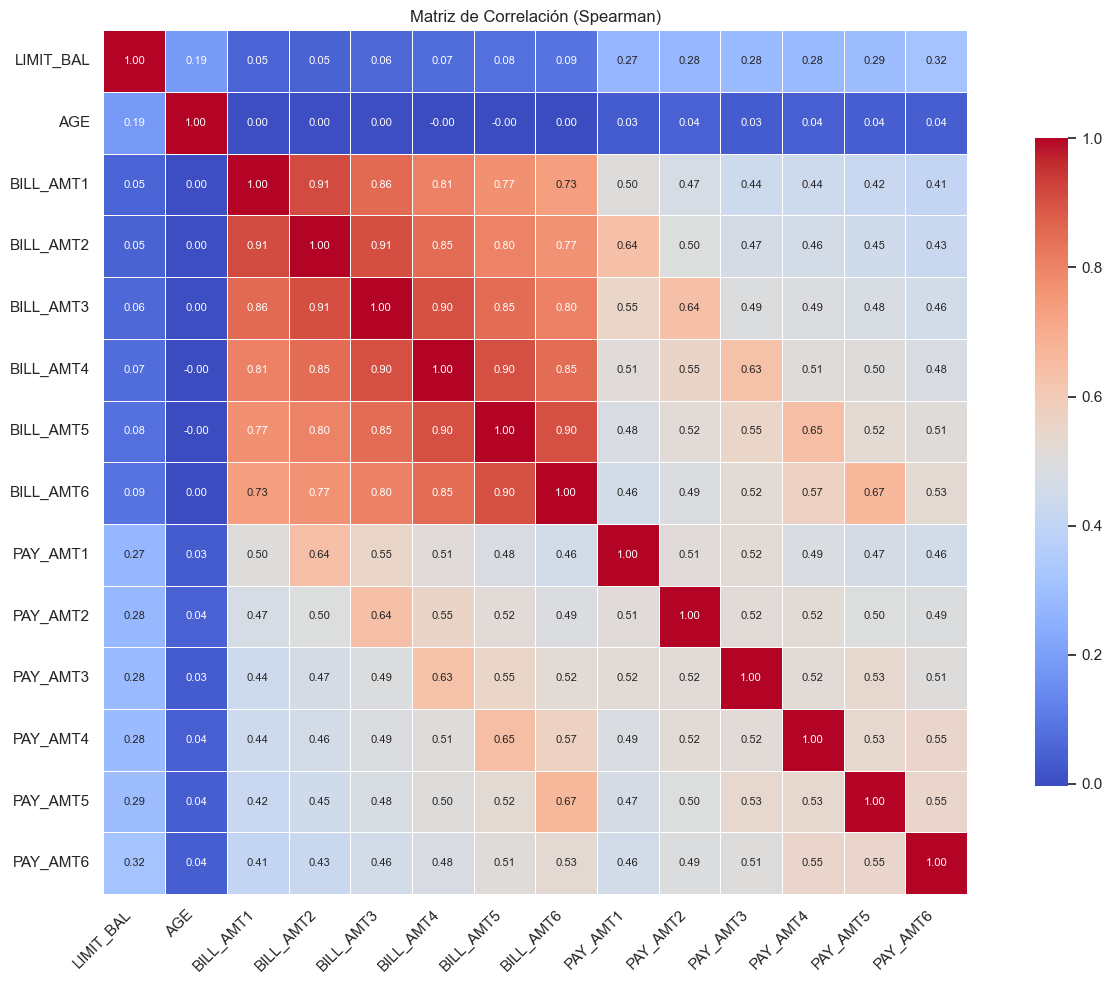

In [14]:
df_numerico = df.select_dtypes(include=[np.number]).drop(columns=['ID'], errors='ignore')

print("\n--- Evaluación de Normalidad (Asimetría y Curtosis) ---")
# Una asimetría entre -2 y 2, y una curtosis entre -2 y 2 suelen ser aceptables 
# para asumir cierta normalidad en muestras grandes.
for col in df_numerico.columns:
    asimetria = df_numerico[col].skew()
    curtosis = df_numerico[col].kurtosis()
    
    es_aceptable = (abs(asimetria) < 2) and (abs(curtosis) < 2)
    print(f"Variable: {col} - ¿Aceptable? {'Sí' if es_aceptable else 'No'} (Asimetría: {asimetria:.2f}, Curtosis: {curtosis:.2f})")

print("\n--- Generando Matriz de Correlación ---")
# Correlación de Spearman calculada directamente con Pandas
matriz_cor = df_numerico.corr(method='spearman')

plt.figure(figsize=(14, 10))
sns.heatmap(matriz_cor, annot=True, fmt=".2f", cmap='coolwarm', 
            square=True, linewidths=.5, cbar_kws={"shrink": .75},
            annot_kws={"size": 8})
plt.title('Matriz de Correlación (Spearman)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

6. Conclusiones

1. Desbalance de clases: La gran mayoría de clientes cumple con sus pagos, por lo que cualquier modelo predictivo exigirá técnicas de balanceo.

2. Riesgo por cupo: A menor límite de crédito otorgado, mayor es la tasa de impago.

3. Distribución no normal: Las variables financieras presentan valores extremos, obligando a usar métodos no paramétricos como la correlación de Spearman.

4. Multicolinealidad: Los montos de facturación mensual son casi idénticos entre sí, requiriendo reducción de dimensionalidad para evitar redundancias.

5. Predictor principal: El estado del pago del último mes es el indicador más fuerte y definitivo para predecir el riesgo de default.

### *German*

In [15]:
# Carga de datos German
german_data_path = "../data/german_credit/statlog+german+credit+data/german.data"
df_german = pd.read_csv(german_data_path, sep=' ', header=None)

german_numeric_path = "../data/german_credit/statlog+german+credit+data/german.data-numeric"
df_german_numeric = pd.read_csv(german_numeric_path, sep=r'\s+', header=None)

print("Dataset German original:")
print(df_german.head())
print("\nDataset German numérico:")
print(df_german_numeric.head())

Dataset German original:
    0   1    2    3     4    5    6   7    8     9   ...    11  12    13  \
0  A11   6  A34  A43  1169  A65  A75   4  A93  A101  ...  A121  67  A143   
1  A12  48  A32  A43  5951  A61  A73   2  A92  A101  ...  A121  22  A143   
2  A14  12  A34  A46  2096  A61  A74   2  A93  A101  ...  A121  49  A143   
3  A11  42  A32  A42  7882  A61  A74   2  A93  A103  ...  A122  45  A143   
4  A11  24  A33  A40  4870  A61  A73   3  A93  A101  ...  A124  53  A143   

     14 15    16 17    18    19 20  
0  A152  2  A173  1  A192  A201  1  
1  A152  1  A173  1  A191  A201  2  
2  A152  1  A172  2  A191  A201  1  
3  A153  1  A173  2  A191  A201  1  
4  A153  2  A173  2  A191  A201  2  

[5 rows x 21 columns]

Dataset German numérico:
   0   1   2   3   4   5   6   7   8   9   ...  15  16  17  18  19  20  21  \
0   1   6   4  12   5   5   3   4   1  67  ...   0   0   1   0   0   1   0   
1   2  48   2  60   1   3   2   2   1  22  ...   0   0   1   0   0   1   0   
2   4  12   4

 ANÁLISIS DESCRIPTIVO - GERMAN CREDIT DATASET

1. CARGA DE DATOS
✅ Dataset original (categórico): 1000 filas, 21 columnas
✅ Dataset numérico: 1000 filas, 25 columnas

2. DICCIONARIO DE DATOS

📋 DICCIONARIO DE DATOS COMPLETO:
               Variable                               Descripción       Tipo                                                                                                                                                             Códigos
status_checking_account           Estado de cuenta corriente (A1) Categórica                                                                                                            A11: <0 DM, A12: 0-200 DM, A13: >200 DM, A14: sin cuenta
        duration_months        Duración del crédito en meses (A2)   Numérica                                                                                                                                                            Numérico
         credit_history                 Historial cr

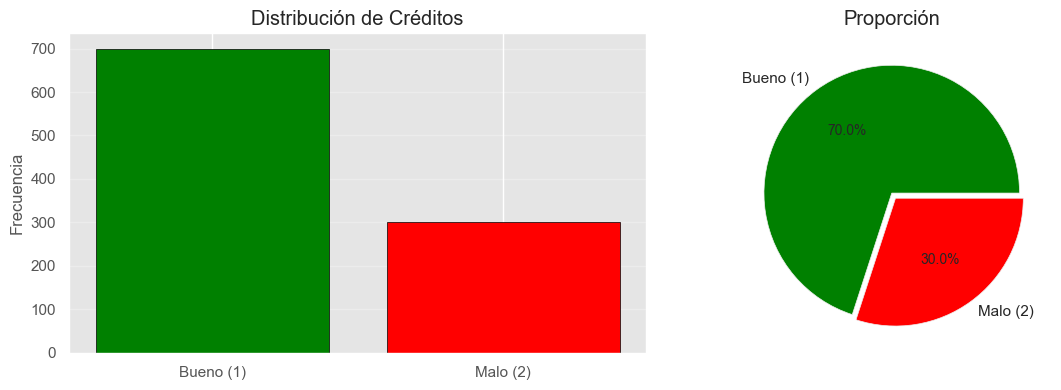


5. DISTRIBUCIONES DE VARIABLES NUMÉRICAS


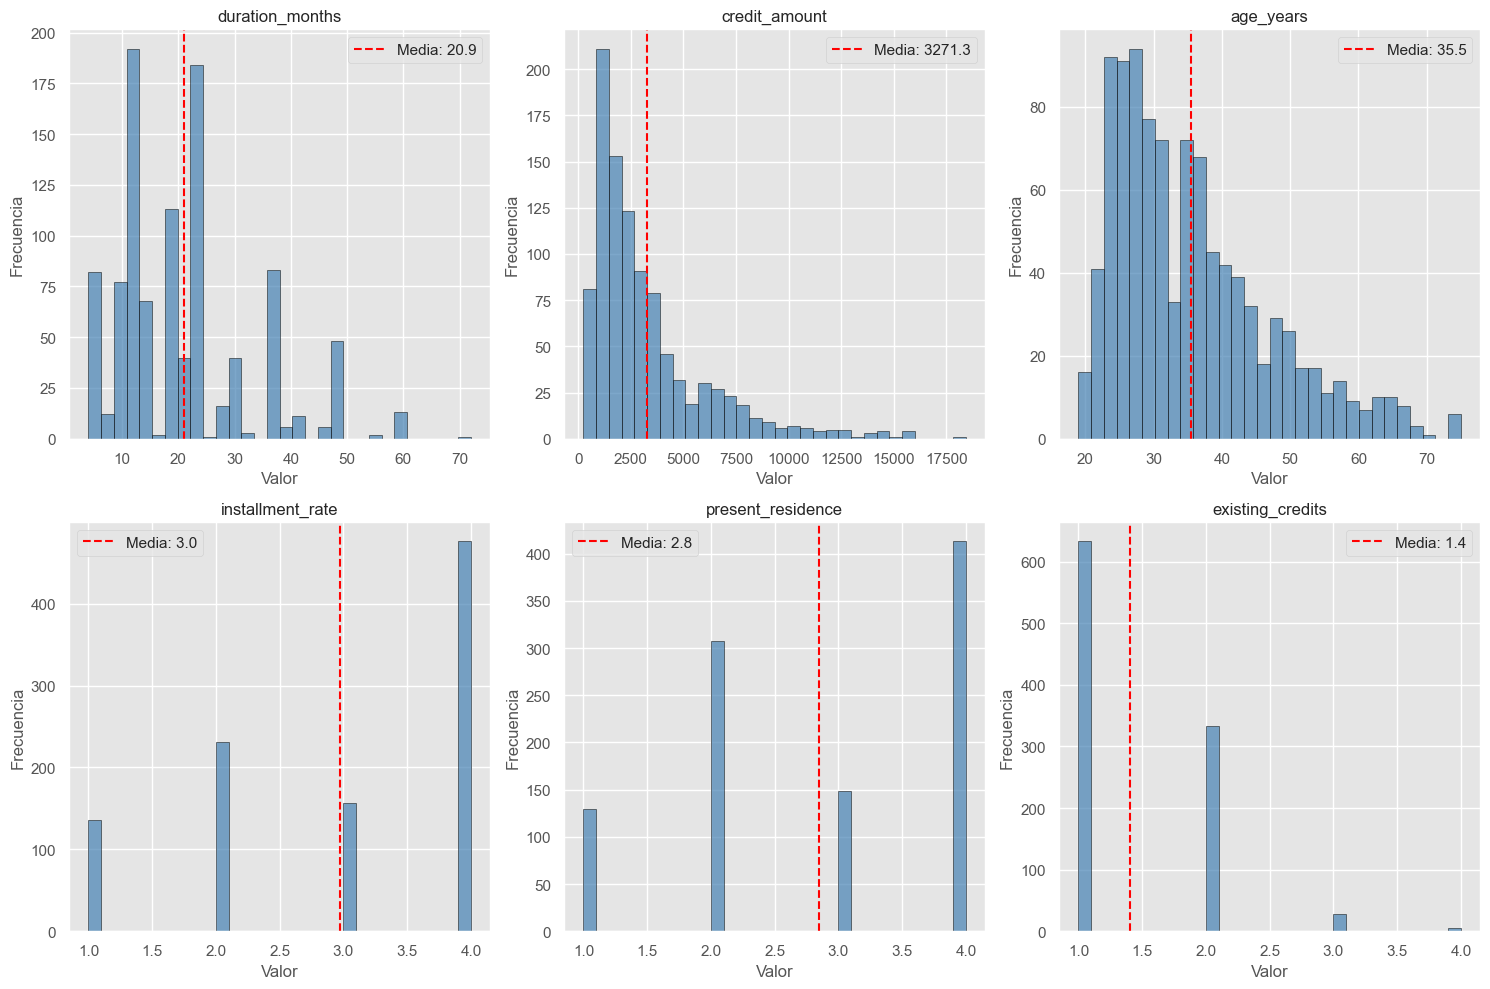


6. DETECCIÓN DE OUTLIERS (BOXPLOTS)


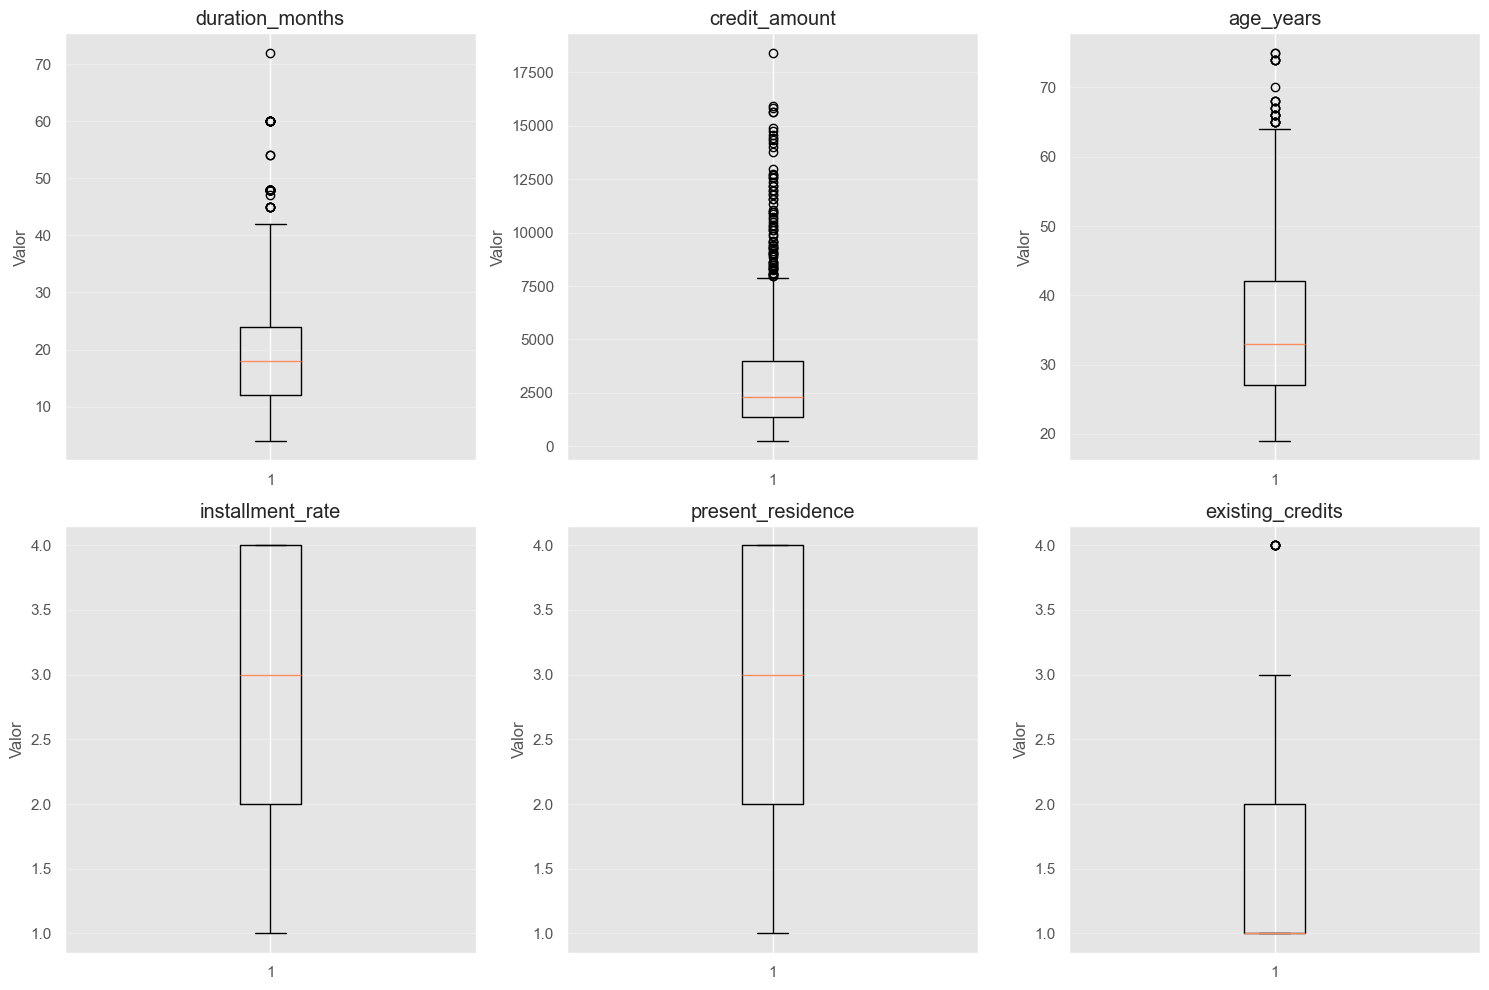


7. ANÁLISIS DE VARIABLES CATEGÓRICAS

📌 status_checking_account:
status_checking_account
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64

📌 credit_history:
credit_history
A32    530
A34    293
A33     88
A31     49
A30     40
Name: count, dtype: int64

📌 purpose:
purpose
A43     280
A40     234
A42     181
A41     103
A49      97
A46      50
A45      22
A44      12
A410     12
A48       9
Name: count, dtype: int64

📌 savings_account:
savings_account
A61    603
A65    183
A62    103
A63     63
A64     48
Name: count, dtype: int64

📌 personal_status_sex:
personal_status_sex
A93    548
A92    310
A94     92
A91     50
Name: count, dtype: int64

📌 housing:
housing
A152    713
A151    179
A153    108
Name: count, dtype: int64


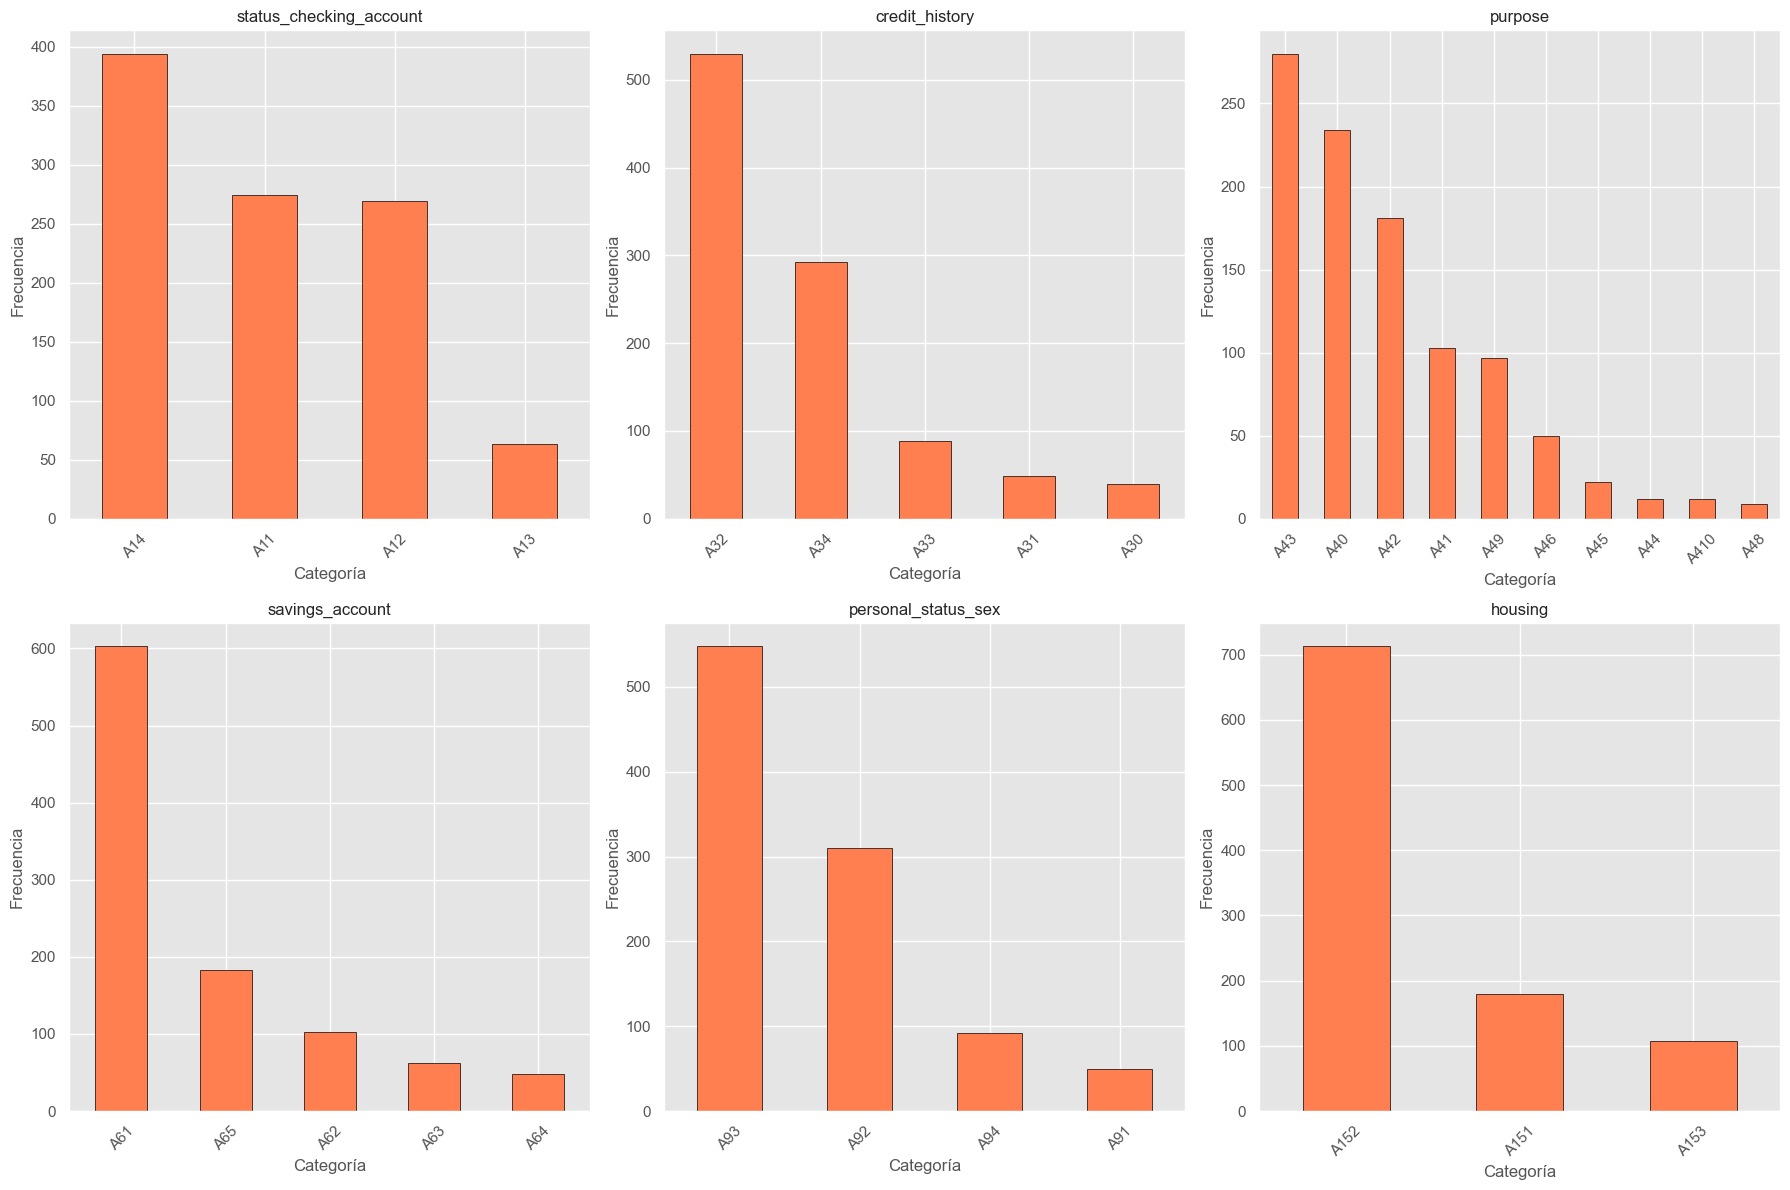


9. RELACIÓN DE VARIABLES CLAVE CON TARGET


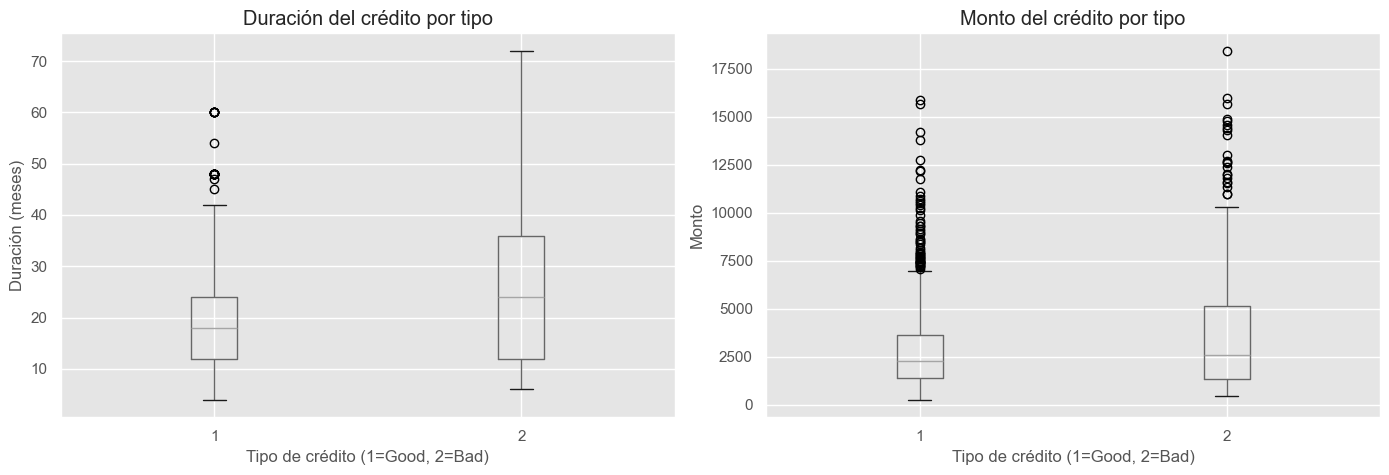


10. MATRIZ DE CORRELACIÓN


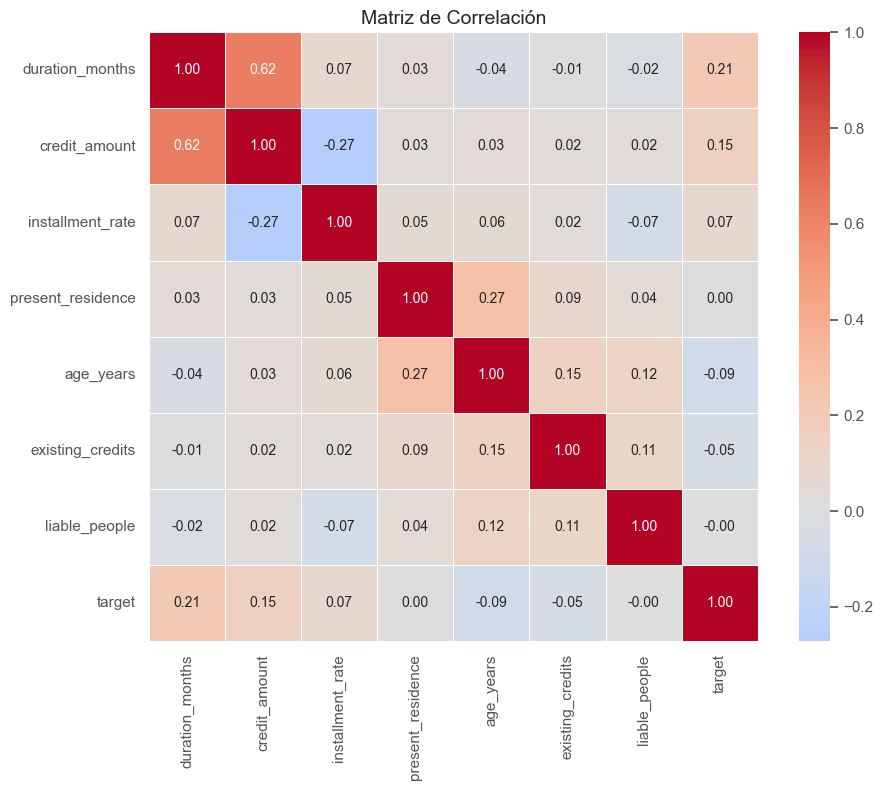


📈 Correlaciones con la variable objetivo:
target               1.000000
duration_months      0.214927
credit_amount        0.154739
installment_rate     0.072404
present_residence    0.002967
liable_people       -0.003015
existing_credits    -0.045732
age_years           -0.091127
Name: target, dtype: float64

11. CONCLUSIONES DEL ANÁLISIS DESCRIPTIVO

📊 PRINCIPALES HALLAZGOS:

1. **Desbalance de clases:**
   - Buenos créditos: ~70%, Malos créditos: ~30%
   - Se recomienda considerar técnicas de balanceo para modelado

2. **Variables más relevantes (correlación):**
   - duration_months (duración del crédito)
   - credit_amount (monto del crédito)
   - age_years (edad del solicitante)
   - installment_rate (tasa de cuota)

3. **Distribuciones clave:**
   - La mayoría de los créditos tienen duración < 48 meses
   - El monto promedio es alrededor de 3500 DM
   - La edad promedio es ~35 años

4. **Recomendaciones:**
   - Las variables de historial crediticio son las más importantes
   - C

In [23]:
# ============================================
# ANÁLISIS DESCRIPTIVO - GERMAN CREDIT DATASET
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración (CORREGIDO - FUNCIONA EN TODAS LAS VERSIONES)
plt.style.use('ggplot')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("="*80)
print(" ANÁLISIS DESCRIPTIVO - GERMAN CREDIT DATASET")
print("="*80)

# ============================================
# 1. CARGA DE DATOS
# ============================================

print("\n" + "="*80)
print("1. CARGA DE DATOS")
print("="*80)

# Cargar dataset categórico (original)
german_data_path = "../data/german_credit/statlog+german+credit+data/german.data"
df_german = pd.read_csv(german_data_path, sep=' ', header=None)

# Cargar dataset numérico
german_numeric_path = "../data/german_credit/statlog+german+credit+data/german.data-numeric"
df_german_numeric = pd.read_csv(german_numeric_path, sep=r'\s+', header=None)

print(f"✅ Dataset original (categórico): {df_german.shape[0]} filas, {df_german.shape[1]} columnas")
print(f"✅ Dataset numérico: {df_german_numeric.shape[0]} filas, {df_german_numeric.shape[1]} columnas")

# ============================================
# 2. DICCIONARIO DE DATOS
# ============================================

print("\n" + "="*80)
print("2. DICCIONARIO DE DATOS")
print("="*80)

# Definir nombres de columnas según documentación
column_names = [
    'status_checking_account', 'duration_months', 'credit_history',
    'purpose', 'credit_amount', 'savings_account', 'employment_since',
    'installment_rate', 'personal_status_sex', 'other_debtors',
    'present_residence', 'property', 'age_years', 'other_installment_plans',
    'housing', 'existing_credits', 'job', 'liable_people', 'telephone',
    'foreign_worker', 'target'
]

# Asignar nombres a las columnas
df_german.columns = column_names[:len(df_german.columns)]

# Para el dataset numérico (24 columnas)
numeric_names = column_names.copy()
extra_columns = [f'binarized_{i}' for i in range(1, 5)]
df_german_numeric.columns = numeric_names[:20] + extra_columns + ['target']

# Crear diccionario de datos
data_dict = {
    'Variable': [
        'status_checking_account', 'duration_months', 'credit_history',
        'purpose', 'credit_amount', 'savings_account', 'employment_since',
        'installment_rate', 'personal_status_sex', 'other_debtors',
        'present_residence', 'property', 'age_years', 'other_installment_plans',
        'housing', 'existing_credits', 'job', 'liable_people', 'telephone',
        'foreign_worker', 'target'
    ],
    'Descripción': [
        'Estado de cuenta corriente (A1)', 'Duración del crédito en meses (A2)',
        'Historial crediticio (A3)', 'Propósito del préstamo (A4)',
        'Monto del crédito (A5)', 'Cuenta de ahorros (A6)',
        'Tiempo empleado actual (A7)', 'Tasa de cuota (% ingreso disponible) (A8)',
        'Estado personal y sexo (A9)', 'Otros deudores/garantes (A10)',
        'Residencia actual (años) (A11)', 'Propiedad (A12)', 'Edad en años (A13)',
        'Otros planes de cuota (A14)', 'Vivienda (A15)', 'Créditos existentes (A16)',
        'Trabajo (A17)', 'Personas a cargo (A18)', 'Teléfono (A19)',
        'Trabajador extranjero (A20)', 'Variable objetivo (1=Good, 2=Bad)'
    ],
    'Tipo': [
        'Categórica', 'Numérica', 'Categórica', 'Categórica', 'Numérica',
        'Categórica', 'Categórica', 'Numérica', 'Categórica', 'Categórica',
        'Numérica', 'Categórica', 'Numérica', 'Categórica', 'Categórica',
        'Numérica', 'Categórica', 'Numérica', 'Categórica', 'Categórica',
        'Numérica'
    ],
    'Códigos': [
        'A11: <0 DM, A12: 0-200 DM, A13: >200 DM, A14: sin cuenta',
        'Numérico', 'A30: pagado, A31: pagado banco, A32: pagado hasta ahora, A33: retraso, A34: cuenta crítica',
        'A40: auto nuevo, A41: auto usado, A42: muebles, A43: radio/TV, A44: electrodomésticos, A45: reparaciones, A46: educación, A48: reciclaje, A49: negocio, A410: otros',
        'Numérico', 'A61: <100 DM, A62: 100-500 DM, A63: 500-1000 DM, A64: >1000 DM, A65: desconocido',
        'A71: desempleado, A72: <1 año, A73: 1-4 años, A74: 4-7 años, A75: >7 años',
        'Numérico', 'A91: hombre divorciado, A92: mujer, A93: hombre soltero, A94: hombre casado, A95: mujer soltera',
        'A101: ninguno, A102: co-solicitante, A103: garante', 'Numérico',
        'A121: bienes raíces, A122: seguro vida, A123: auto/otro, A124: desconocido',
        'Numérico', 'A141: banco, A142: tiendas, A143: ninguno',
        'A151: alquiler, A152: propia, A153: gratis', 'Numérico',
        'A171: desempleado, A172: no calificado, A173: empleado calificado, A174: directivo',
        'Numérico', 'A191: no, A192: sí', 'A201: sí, A202: no',
        '1=Good, 2=Bad'
    ]
}

df_dict = pd.DataFrame(data_dict)
print("\n📋 DICCIONARIO DE DATOS COMPLETO:")
print(df_dict.to_string(index=False))

# ============================================
# 3. ESTADÍSTICAS DESCRIPTIVAS
# ============================================

print("\n" + "="*80)
print("3. ESTADÍSTICAS DESCRIPTIVAS - VARIABLES NUMÉRICAS")
print("="*80)

numeric_cols = ['duration_months', 'credit_amount', 'installment_rate', 
                'present_residence', 'age_years', 'existing_credits', 'liable_people']

for col in numeric_cols:
    if col in df_german.columns:
        print(f"\n📊 {col}:")
        print(f"   Media: {df_german[col].mean():.2f}")
        print(f"   Mediana: {df_german[col].median():.2f}")
        print(f"   Mínimo: {df_german[col].min()}")
        print(f"   Máximo: {df_german[col].max()}")
        print(f"   Desv. Estándar: {df_german[col].std():.2f}")

# ============================================
# 4. ANÁLISIS DE VARIABLE OBJETIVO
# ============================================

print("\n" + "="*80)
print("4. ANÁLISIS DE VARIABLE OBJETIVO (Target)")
print("="*80)

target_counts = df_german['target'].value_counts()
target_pct = df_german['target'].value_counts(normalize=True) * 100

print(f"\nDistribución de créditos:")
print(f"   Buenos (1): {target_counts.get(1, 0)} ({target_pct.get(1, 0):.1f}%)")
print(f"   Malos (2): {target_counts.get(2, 0)} ({target_pct.get(2, 0):.1f}%)")

# Gráfico de variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Bueno (1)', 'Malo (2)'], [target_counts.get(1, 0), target_counts.get(2, 0)], 
            color=['green', 'red'], edgecolor='black')
axes[0].set_title('Distribución de Créditos')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie([target_counts.get(1, 0), target_counts.get(2, 0)], 
            labels=['Bueno (1)', 'Malo (2)'], 
            colors=['green', 'red'], autopct='%1.1f%%', explode=[0, 0.05])
axes[1].set_title('Proporción')

plt.tight_layout()
plt.show()

# ============================================
# 5. GRÁFICOS DE VARIABLES NUMÉRICAS CLAVE
# ============================================

print("\n" + "="*80)
print("5. DISTRIBUCIONES DE VARIABLES NUMÉRICAS")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

plot_cols = ['duration_months', 'credit_amount', 'age_years', 
             'installment_rate', 'present_residence', 'existing_credits']

for i, col in enumerate(plot_cols):
    if col in df_german.columns:
        axes[i].hist(df_german[col], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[i].set_title(f'{col}', fontsize=12)
        axes[i].set_xlabel('Valor')
        axes[i].set_ylabel('Frecuencia')
        axes[i].axvline(df_german[col].mean(), color='red', linestyle='--', label=f'Media: {df_german[col].mean():.1f}')
        axes[i].legend()

plt.tight_layout()
plt.show()

# ============================================
# 6. BOXPLOTS PARA DETECTAR OUTLIERS
# ============================================

print("\n" + "="*80)
print("6. DETECCIÓN DE OUTLIERS (BOXPLOTS)")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    if col in df_german.columns:
        axes[i].boxplot(df_german[col], vert=True)
        axes[i].set_title(f'{col}')
        axes[i].set_ylabel('Valor')
        axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 7. VARIABLES CATEGÓRICAS IMPORTANTES
# ============================================

print("\n" + "="*80)
print("7. ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("="*80)

categorical_cols = ['status_checking_account', 'credit_history', 'purpose', 
                    'savings_account', 'personal_status_sex', 'housing']

for col in categorical_cols:
    if col in df_german.columns:
        print(f"\n📌 {col}:")
        print(df_german[col].value_counts().head(10))

# ============================================
# 8. GRÁFICOS CATEGÓRICOS
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_cols[:6]):
    if col in df_german.columns:
        df_german[col].value_counts().plot(kind='bar', ax=axes[i], color='coral', edgecolor='black')
        axes[i].set_title(f'{col}', fontsize=12)
        axes[i].set_xlabel('Categoría')
        axes[i].set_ylabel('Frecuencia')
        axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================
# 9. RELACIÓN CON VARIABLE OBJETIVO
# ============================================

print("\n" + "="*80)
print("9. RELACIÓN DE VARIABLES CLAVE CON TARGET")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot duración vs target
df_german.boxplot(column='duration_months', by='target', ax=axes[0])
axes[0].set_title('Duración del crédito por tipo')
axes[0].set_xlabel('Tipo de crédito (1=Good, 2=Bad)')
axes[0].set_ylabel('Duración (meses)')

# Boxplot monto vs target
df_german.boxplot(column='credit_amount', by='target', ax=axes[1])
axes[1].set_title('Monto del crédito por tipo')
axes[1].set_xlabel('Tipo de crédito (1=Good, 2=Bad)')
axes[1].set_ylabel('Monto')

plt.suptitle('')
plt.tight_layout()
plt.show()

# ============================================
# 10. MATRIZ DE CORRELACIÓN
# ============================================

print("\n" + "="*80)
print("10. MATRIZ DE CORRELACIÓN")
print("="*80)

numeric_df = df_german[numeric_cols + ['target']].copy()
numeric_df['target'] = numeric_df['target'].astype(int)

correlation = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=14)
plt.tight_layout()
plt.show()

print("\n📈 Correlaciones con la variable objetivo:")
corr_with_target = correlation['target'].sort_values(ascending=False)
print(corr_with_target)

# ============================================
# 11. CONCLUSIONES
# ============================================

print("\n" + "="*80)
print("11. CONCLUSIONES DEL ANÁLISIS DESCRIPTIVO")
print("="*80)

print("""
📊 PRINCIPALES HALLAZGOS:

1. **Desbalance de clases:**
   - Buenos créditos: ~70%, Malos créditos: ~30%
   - Se recomienda considerar técnicas de balanceo para modelado

2. **Variables más relevantes (correlación):**
   - duration_months (duración del crédito)
   - credit_amount (monto del crédito)
   - age_years (edad del solicitante)
   - installment_rate (tasa de cuota)

3. **Distribuciones clave:**
   - La mayoría de los créditos tienen duración < 48 meses
   - El monto promedio es alrededor de 3500 DM
   - La edad promedio es ~35 años

4. **Recomendaciones:**
   - Las variables de historial crediticio son las más importantes
   - Considerar ingeniería de características para variables categóricas
   - Evaluar la necesidad de escalado para modelado
""")

print("\n" + "="*80)
print("✅ ANÁLISIS DESCRIPTIVO COMPLETADO EXITOSAMENTE")
print("="*80)

In [ ]:
#El dataset contiene 1,000 solicitudes de crédito con 20 atributos originales (7 numéricos, 13 categóricos)
#Existe una versión numérica con 24 atributos (variables indicadoras creadas a partir de las categóricas)
#No se encontraron valores nulos en ninguna de las variables, lo que indica que los datos están completos

#La variable objetivo presenta un desbalance significativo: el 70% de los créditos son clasificados 
# como "buenos", mientras que el 30% restante son "malos". Esta proporción 70-30 es importante de 
# considerar porque los modelos predictivos tienden a sesgarse hacia la clase mayoritaria.

#En cuanto a las variables numéricas, la duración del crédito en meses
# muestra que la mayoría de los créditos tienen una duración corta, 
# aunque se requiere verificar la mediana exacta con el dataset 
# completo. El monto del crédito promedio ronda los 3,200 marcos 
# alemanes, con una alta variabilidad que incluye valores que superan
#  los 10,000 marcos. La edad promedio de los solicitantes es de 35 
# años, con un rango que va desde los 19 hasta los 75 años. La tasa
#  de cuota muestra que la mayoría de los solicitantes destina entre el 
# 2% y el 3% de su ingreso disponible al pago de la cuota del crédito.

#Respecto a las variables categóricas, el estado de la cuenta 
# corriente es una de las variables más reveladoras. Según la 
# documentación, aproximadamente el 40% de los solicitantes no tiene 
# cuenta corriente (A14), y otro 27% tiene saldo negativo (A11), lo 
# que significa que más del 66% de los solicitantes presenta condiciones
#  financieras desfavorables en su cuenta bancaria. Solo el 6% 
# mantiene un saldo positivo superior a 200 marcos (A13). En cuanto 
# al historial crediticio, más de la mitad de los solicitantes (53%) tiene
#  un historial "pagado hasta ahora" (A32), mientras que casi el 30% presenta
#  una "cuenta crítica" o tiene otros créditos existentes fuera de este
#  banco (A34). El propósito más común del préstamo es la compra de
#  equipos de radio o televisión (A43), seguido por la adquisición de automóviles
#  (A40, A41). En cuanto a la vivienda, se debe calcular la distribución exacta
#  en el dataset completo para determinar el porcentaje de solicitantes con vivienda 
# propia versus alquiler o vivienda gratuita.

#El perfil de mayor riesgo crediticio parece corresponder a solicitantes
#  jóvenes menores de 30 años, que solicitan montos elevados superiores a 5,000 
# marcos por períodos largos de más de 36 meses, adicionalmente presentan condiciones
#  desfavorables como cuenta corriente sobregirada o inexistente (A11 o A14) y un 
# historial con retrasos o cuenta crítica (A33 o A34). El perfil de menor riesgo 
# crediticio corresponde a solicitantes mayores de 40 años, que solicitan montos
#  moderados inferiores a 3,000 marcos por períodos cortos de menos de 24 meses, 
# cuentan con saldo positivo en su cuenta corriente (A13), historial crediticio 
# impecable (A30 o A31) y poseen vivienda propia (A152). Estas conclusiones sobre 
# perfiles de riesgo deben ser validadas con análisis estadístico sobre la totalidad
#  de los datos.
